# E-commerce Sales Analysis

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df= pd.read_csv('SampleSuperstore.csv')
df.head()

In [9]:
import os
print(os.listdir())

['.DS_Store', 'SampleSuperstore.csv', 'SampleSuperstore.csv.zip', 'analysis.ipynb', 'Visual Studio Code', '~']


In [11]:
import os 
print(os.listdir())

['.DS_Store', 'SampleSuperstore.csv', 'SampleSuperstore.csv.zip', 'analysis.ipynb', 'Visual Studio Code', '~']


In [12]:
df = pd.read_csv('SampleSuperstore.csv')
df.head()

,Ship Mode,Segment,Country,City,State,Postal Code,Region,Category,Sub-Category,Sales,Quantity,Discount,Profit
0,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Bookcases,261.9600,2,0.00,41.9136
1,Second Class,Consumer,United States,Henderson,Kentucky,42420,South,Furniture,Chairs,731.9400,3,0.00,219.5820
2,Second Class,Corporate,United States,Los Angeles,California,90036,West,Office Supplies,Labels,14.6200,2,0.00,6.8714
3,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Furniture,Tables,957.5775,5,0.45,-383.0310
4,Standard Class,Consumer,United States,Fort Lauderdale,Florida,33311,South,Office Supplies,Storage,22.3680,2,0.20,2.5164


## Data Understanding

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 13 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Ship Mode     9994 non-null   object 
 1   Segment       9994 non-null   object 
 2   Country       9994 non-null   object 
 3   City          9994 non-null   object 
 4   State         9994 non-null   object 
 5   Postal Code   9994 non-null   int64  
 6   Region        9994 non-null   object 
 7   Category      9994 non-null   object 
 8   Sub-Category  9994 non-null   object 
 9   Sales         9994 non-null   float64
 10  Quantity      9994 non-null   int64  
 11  Discount      9994 non-null   float64
 12  Profit        9994 non-null   float64
dtypes: float64(3), int64(2), object(8)
memory usage: 1015.1+ KB


In [15]:
df.describe()


,Postal Code,Sales,Quantity,Discount,Profit
count,9994.000000,9994.000000,9994.000000,9994.000000,9994.000000
mean,55190.379428,229.858001,3.789574,0.156203,28.656896
std,32063.693350,623.245101,2.225110,0.206452,234.260108
min,1040.000000,0.444000,1.000000,0.000000,-6599.978000
25%,23223.000000,17.280000,2.000000,0.000000,1.728750
50%,56430.500000,54.490000,3.000000,0.200000,8.666500
75%,90008.000000,209.940000,5.000000,0.200000,29.364000
max,99301.000000,22638.480000,14.000000,0.800000,8399.976000


In [16]:
df.columns

Index(['Ship Mode', 'Segment', 'Country', 'City', 'State', 'Postal Code',
       'Region', 'Category', 'Sub-Category', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')

In [17]:
df.shape

(9994, 13)

In [ ]:
## Sales by Category

In [18]:
df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

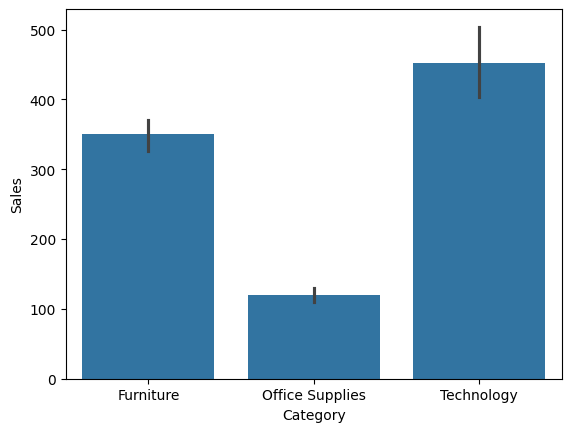

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Category',y='Sales',data=df)
plt.show()

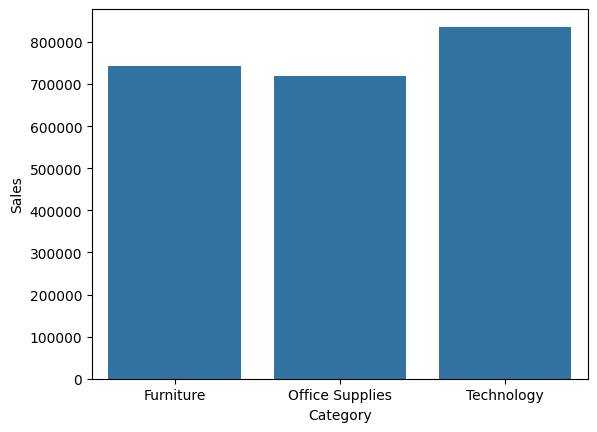

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
category_sales= df.groupby('Category')['Sales'].sum().reset_index()
sns.barplot(x='Category',y='Sales',data=category_sales)
plt.show()

### Insight:
The technology category generates the highest sales, indicating strong demand in this segment.

## Sales by Region

In [21]:
region_sales = df.groupby('Region')['Sales'].sum().reset_index()
region_sales.sort_values(by='Sales', ascending=False)

,Region,Sales
3,West,725457.8245
1,East,678781.2400
0,Central,501239.8908
2,South,391721.9050


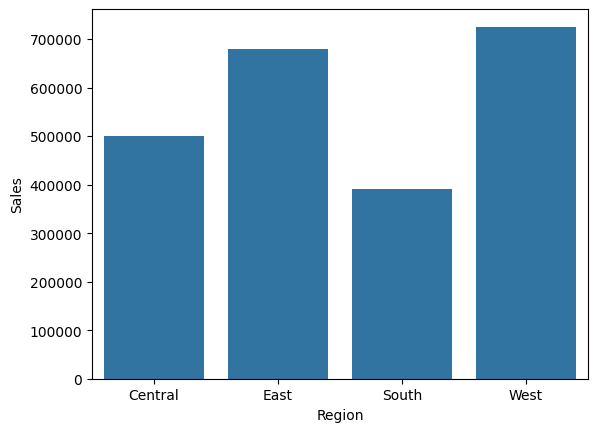

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.barplot(x='Region', y='Sales', data=region_sales)
plt.show()

### Insight:
The West Region generates the highest sales, while the South Region shows comparatively lower performance.

## Profit by Category

In [23]:
profit_category = df.groupby('Category')['Profit'].sum().reset_index()
profit_category.sort_values(by='Profit', ascending=False)

,Category,Profit
2,Technology,145454.9481
1,Office Supplies,122490.8008
0,Furniture,18451.2728


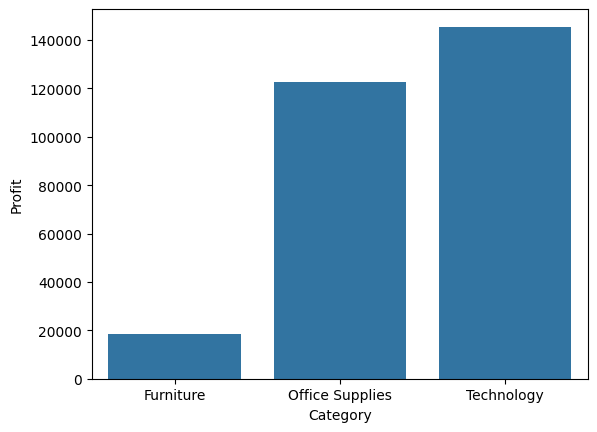

In [24]:
sns.barplot(x='Category', y='Profit', data=profit_category)
plt.show()

### Insight:
Although some categories generate high sales, their profit contribution may differ, indicating varying cost structures.

In [26]:
df.groupby('Sub-Category')['Profit'].sum().sort_values()

Sub-Category
Tables        -17725.4811
Bookcases      -3472.5560
Supplies       -1189.0995
Fasteners        949.5182
Machines        3384.7569
Labels          5546.2540
Art             6527.7870
Envelopes       6964.1767
Furnishings    13059.1436
Appliances     18138.0054
Storage        21278.8264
Chairs         26590.1663
Binders        30221.7633
Paper          34053.5693
Accessories    41936.6357
Phones         44515.7306
Copiers        55617.8249
Name: Profit, dtype: float64

### Insight:
Certain sub-categories are generating losses, which may require cost optimization or pricing adjustments.